In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/pet_adoption_data.csv')

y = df['AdoptionLikelihood']
X = df.drop('AdoptionLikelihood', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

--Własna metryka--

In [4]:
def shelter_score(y_true, y_proba, budzet=200, koszt_reklamy=10):
    if y_proba.ndim == 2:
        y_proba = y_proba[:, 1]

    max_reklam = budzet // koszt_reklamy 
    
    wyniki = pd.DataFrame({'y_true': y_true, 'proba': y_proba})
    wyniki_posortowane = wyniki.sort_values(by='proba', ascending=False)
    
    wybrane = wyniki_posortowane.head(max_reklam)
    
    tp = (wybrane['y_true'] == 1).sum()
    fp = (wybrane['y_true'] == 0).sum()
    
    oczekiwana_liczba_adopcji = (tp * 0.70) + (fp * 0.10)
    
    return oczekiwana_liczba_adopcji

--Porównanie modeli--

In [5]:
import joblib

model_NB = joblib.load('NB_shelter_model.pkl')

try:
    model_Tree = joblib.load('Tree_shelter_model.pkl')
except FileNotFoundError:
    print("Plik Tree_shelter_model.pkl nie istnieje. Uruchom najpierw notatnik drzewo_decyzyjne.ipynb")
    model_Tree = None

model_Reg = joblib.load("model_logreg.pkl")

NaiveBayes - ilosc zwierzat: 14.00
DecisionTree - ilosc zwierzat: 13.40
LogisticRegresion - ilosc zwierzat: 14.00


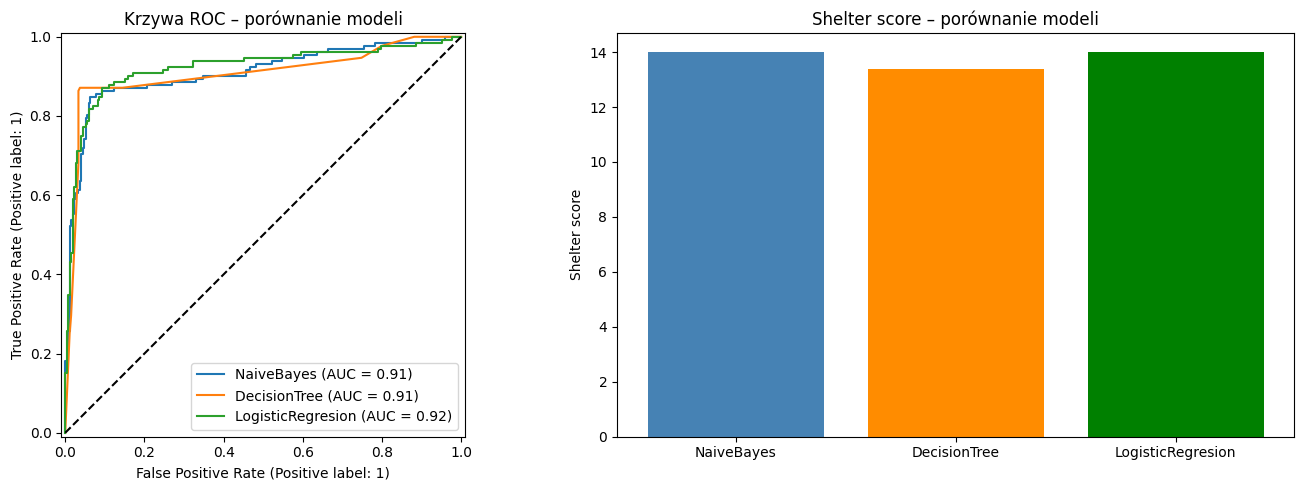

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import RocCurveDisplay, roc_auc_score, precision_score

modele = {
    'NaiveBayes': model_NB,
    'DecisionTree': model_Tree,
    'LogisticRegresion': model_Reg
}
modele = {k: v for k, v in modele.items() if v is not None}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nazwa, model in modele.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    print(f"{nazwa} - ilosc zwierzat: {shelter_score(y_test, y_prob):.2f}")
    
    # ROC
    RocCurveDisplay.from_predictions(y_test, y_prob,
                                     name=f'{nazwa}',
                                     ax=axes[0])

axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('Krzywa ROC – porównanie modeli')

scores = {nazwa: shelter_score(y_test, model.predict_proba(X_test)[:, 1]) 
          for nazwa, model in modele.items()}
axes[1].bar(scores.keys(), scores.values(), color=['steelblue', 'darkorange', 'green'][:len(scores)])
axes[1].set_title('Shelter score – porównanie modeli')
axes[1].set_ylabel('Shelter score')

plt.tight_layout()
plt.show()


In [7]:
import pandas as pd

def estymuj_szanse_adopcji(model, cechy_zwierzaka):
    df_nowy = pd.DataFrame([cechy_zwierzaka])
    
    prawdopodobienstwo = model.predict_proba(df_nowy)[0][1]
    
    return prawdopodobienstwo


nowy_zwierzak = {
    'PetType': 'Dog',
    'Breed': 'Labrador',
    'AgeMonths': 24,            
    'WeightKg': 15.5,           
    'TimeInShelterDays': 10, 
    'Color': 'Black',
    'Size': 'Medium',
    'Vaccinated': 1,
    'HealthCondition': 0,
    'Dewormed': 1,
    'Sterilized': 1,
    'AdoptionFee': 50,
    'Gender': 0,
    'PreviousOwner': 0
}


szansa = estymuj_szanse_adopcji(model_Tree, nowy_zwierzak)
print(f"Szansa: {szansa:.2%}")


Szansa: 91.30%
